In [1]:
#Imports 
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
#from DiscEvolution.eos import LocallyIsothermalEOS  
#from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
#from DiscEvolution.disc import AccretionDisc
#from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.internal_photo import ConstantInternalPhotoevap

from DiscEvolution.chemistry import SimpleCNOAtomAbund, EquilibriumCNOChemOberg

# Increase resolution (DPI) for better quality
plt.rcParams['figure.dpi'] = 300 

In [2]:
#Initialized but value given in next cell
M_disk_0 = None
Rc = None
R_in = None
Mdot_0 = None
Mstar = None
Rstar = None
# LBP surface density profile with gamma = 1: Sigma(r) = (M_disk / (2*pi*Rc*r)) * exp(-r/Rc)
def Sigma_LBP_1(r) -> float:
    val = (M_disk_0)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

def Temperature(r) -> float:
    T_0 = 150 * u.K 
    val  = T_0 * (r / (1.0 * u.AU))**(-1/2)
    if val.cgs.unit != u.K:
        print('Temperature error')
        return 0
    return val.cgs

def Omega(r) -> float:
    val = np.sqrt((const.G*Mstar)/(r**3))
    if (val.cgs.unit != (1 / u.s)): 
        print("Omega error")
        return 0
    return val.cgs

def c_s(r) -> float:
    val = np.sqrt((const.k_B*Temperature(r))/(mu*const.m_p))
    if (val.cgs.unit != (u.cm / u.s)): 
        print("c_s error")
        return 0
    return val.cgs

def H(r) -> float: 
    val = c_s(r)/Omega(r)
    if val.cgs.unit != (u.cm):
        print("H error")
        return 0
    return val.cgs

#Given Mdisk, Mdot(0), Rc -> Calculate alpha and Sigma0
def calculateAlpha() -> float:
    Rin_cgs = (R_in * u.AU).to(u.cm)               #cm
    Mdot_cgs = Mdot_0.to(u.g / u.s).value  # g/s
    M_disk_cgs = M_disk_0.cgs.value         #g
    cs_val = c_s(Rin_cgs).value                   # cm/s
    omega = Omega(Rin_cgs).value                   # 1/s
    Rc_cgs = Rc.cgs.value               #cm
    alpha = Mdot_cgs*((2*Rin_cgs.value*omega)/3) * (Rc_cgs/((cs_val**2) * M_disk_cgs))
    return alpha 

In [3]:
t_final = 1 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.05 * u.solMass
Mdot_0 = 1E-8 * u.solMass / u.yr  #Armitage p.21
Rc = 100.0 * u.AU
Mstar = 1.0 * u.solMass
Rstar = 2.5 * u.solRad

alpha_eff = 1e-3
psi = 0.01
alpha_turb = alpha_eff / (1.0 + psi)   
alpha_wind = psi * alpha_turb          #Not used for calculations, just for prints

print(f"\nalpha_eff: {alpha_eff:.2e}")
print(f"alpha_turb: {alpha_turb:.2e}")
print(f"alpha_wind: {alpha_wind:.2e}")


alpha_eff: 1.00e-03
alpha_turb: 9.90e-04
alpha_wind: 9.90e-06


In [4]:
# 1) Create grid
R_in = 0.1 #AU
R_out = 1000.0  # AU
Ncells = 500
grid = Grid(R_in, R_out, Ncells, spacing='natural')

In [5]:
# 2) Create star
star = SimpleStar(M = Mstar.value ,R = Rstar.value, T_eff = 4000.0)  #Msun, Rsun, K

In [6]:
# 3) Create EOS 
eos = IrradiatedEOS(
    star,
    alpha_t=alpha_turb,   # Turbulent alpha
    Tc=10,                # External/nebular temperature floor (K)
    Tmax=1500,            # Maximum temperature cap (K)
    mu=2.33,
    gamma=1.0,
    accrete=True,          # Include viscous heating from accretion
    kappa=Zhu2012
)

eos.set_grid(grid)

In [7]:
# 4) Create surface density array from LBP profile
R_centers = grid.Rc  # AU
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU).value for r in R_centers])

eos.update(0, Sigma_initial)

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:459: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


In [ ]:
# 5) Create the disc with dust
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              # Initial dust-to-gas ratio (1%)
    Sigma=Sigma_initial,
    feedback=True,         # Dust affects gas dynamics
    f_ice=1,             # Ice fraction (affects fragmentation)
    uf_0=100,             # Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           # Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             # Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0) #This is to have the pebble size and stokes number correct at t=0

In [9]:
# 6) Set up viscous evolution
visc_evol = HybridWindModel(psi_DW=psi, lambda_DW=3, tol=0.5, boundary='power_law', in_bound='Mdot')
disc._gas = visc_evol #FIXES AN ERROR IN TORQUE CALCS

In [10]:
# 6.2) Add Chemistry
# Create chemistry solver
chem_model = EquilibriumCNOChemOberg(fix_ratios=False, a=1e-5)

# Set solar abundances
X_solar = SimpleCNOAtomAbund(disc.Ncells)
X_solar.set_solar_abundances()

# Iterate to convergence (ice fraction changes dust-to-gas ratio)
for i in range(10):
    chem = chem_model.equilibrium_chem(
        disc.T, 
        disc.midplane_gas_density,
        disc.dust_frac.sum(0), 
        X_solar
    )
    disc.initialize_dust_density(chem.ice.total_abund)

# Attach to disc
disc.chem = chem
disc.update_ices(disc.chem.ice)

drift = SingleFluidDrift(diffusion=None, settling=True)

driver = PlanetDiscDriver(
    disc, 
    gas=visc_evol, 
    dust=drift,
    chemistry=chem_model,  #Driver will handle updating chemistry for gas and ices
    t0=0.0
)

In [11]:
# 7) Setup evolution 
#Check timestep size
dt_max = visc_evol.max_timestep(disc) / yr_code #TODO seems like dt_max is not actually correct, or at least the evolution overrides it
print(f"dt_max = {dt_max:.1f} years")
print(f"Estimated steps: {t_final_code/dt_max:.0f}")

#Output times (in code units)
output_times_yr = np.linspace(0, t_final_yr, 11)  # Every 100 kyr
output_times_code = output_times_yr * yr_code
snapshot_times_yr = np.array([1e5, 5e5, 1e6])  # Snapshot times in years
snapshot_times_code = snapshot_times_yr * yr_code  # Convert to code units
io = Event_Controller(save=output_times_code, snapshot=snapshot_times_code)

history = {'t_yr': [], 'Mtot': [], 'Rout': [], 'dt_yr': []}
snapshots = {'t_yr': [], 'Sigma_G': [], 'Sigma_D': [], 'dust_frac': [], 'St': [], 'grain_size': [], 'T': [], 'P': [], 'chem_ice': [], 'chem_gas': []}

#t = 0 history 
dt_current = visc_evol.max_timestep(disc)
history['t_yr'].append(driver.t / yr_code)
history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))
history['Rout'].append(disc.Rout())
history['dt_yr'].append(dt_current / yr_code)

#t = 0 snapshot
snapshots['t_yr'].append(0.0)
snapshots['Sigma_G'].append(disc.Sigma_G.copy())
snapshots['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy()) #Total dust Sigma, pebbles + grains
snapshots['dust_frac'].append(disc.dust_frac.sum(axis=0).copy()) #Total dust to gas ratio
snapshots['St'].append(disc.Stokes()[1].copy())  #Pebbles not small grains
snapshots['grain_size'].append(disc.grain_size[1].copy()) #Pebbles not small grains
snapshots['T'].append(disc.T.copy()) #Temp
snapshots['P'].append(disc.P.copy()) #Pressure
snapshots['chem_ice'].append(disc.chem.ice.data.copy())
snapshots['chem_gas'].append(disc.chem.gas.data.copy())

dt_max = 62.9 years
Estimated steps: 99939


In [12]:
# 8) Evolve disc
pbar = tqdm(total=t_final_yr,
             unit='yr', 
             desc='Evolving disc... ', 
            bar_format='{desc}: {percentage:.1f}%|{bar}| {n:.0f}/{total:.0f} yr {rate_fmt} [{elapsed}<{remaining}]')
last_t_yr = 0.0
steps = 0

while not io.finished():
    ti = io.next_event_time()

    while driver.t < ti:
        dt = driver(ti)
        steps += 1
        
        #pbar progress
        t_yr = driver.t / yr_code
        pbar.update(t_yr - last_t_yr)
        last_t_yr = t_yr

    # Store snapshots at snapshot times
    if io.check_event(driver.t, 'snapshot'):
        snapshots['t_yr'].append(t_yr)
        snapshots['Sigma_G'].append(disc.Sigma_G.copy())
        snapshots['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy()) #Total dust Sigma, pebbles + grains
        snapshots['dust_frac'].append(disc.dust_frac.sum(axis=0).copy()) #Total dust to gas ratio
        snapshots['St'].append(disc.Stokes()[1].copy()) #Pebbles not small grains
        snapshots['grain_size'].append(disc.grain_size[1].copy()) #Pebbles not small grains
        snapshots['T'].append(disc.T.copy()) #Temp
        snapshots['P'].append(disc.P.copy()) #Pressure
        snapshots['chem_ice'].append(disc.chem.ice.data.copy()) #ice chemistry
        snapshots['chem_gas'].append(disc.chem.gas.data.copy()) #gas chemistry
        io.pop_events(driver.t, 'snapshot')

    # Store at output times
    if io.check_event(driver.t, 'save'):
        dt_current = visc_evol.max_timestep(disc)
        history['t_yr'].append(driver.t / yr_code)
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))
        history['Rout'].append(disc.Rout())
        history['dt_yr'].append(dt_current / yr_code)
        io.pop_events(driver.t, 'save')
        
pbar.close()
print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")
print(f"Average dt: {np.mean(history['dt_yr']):.1f} years")


Evolving disc... : 0.0%|          | 0/1000000 yr ?yr/s [00:00<?]

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/dust.py:435: RuntimeWarning: overflow encountered in exp
  amax = np.minimum(a0, a*np.exp(dt/t_grow))  # If dust grains start small (default) first have to grow)



=== EVOLUTION COMPLETE ===
Total steps: 13979
Final time: 1.0e+06 years
Final mass: 4.738e-02 M_sun (94.9% of initial)
Average dt: 89.3 years


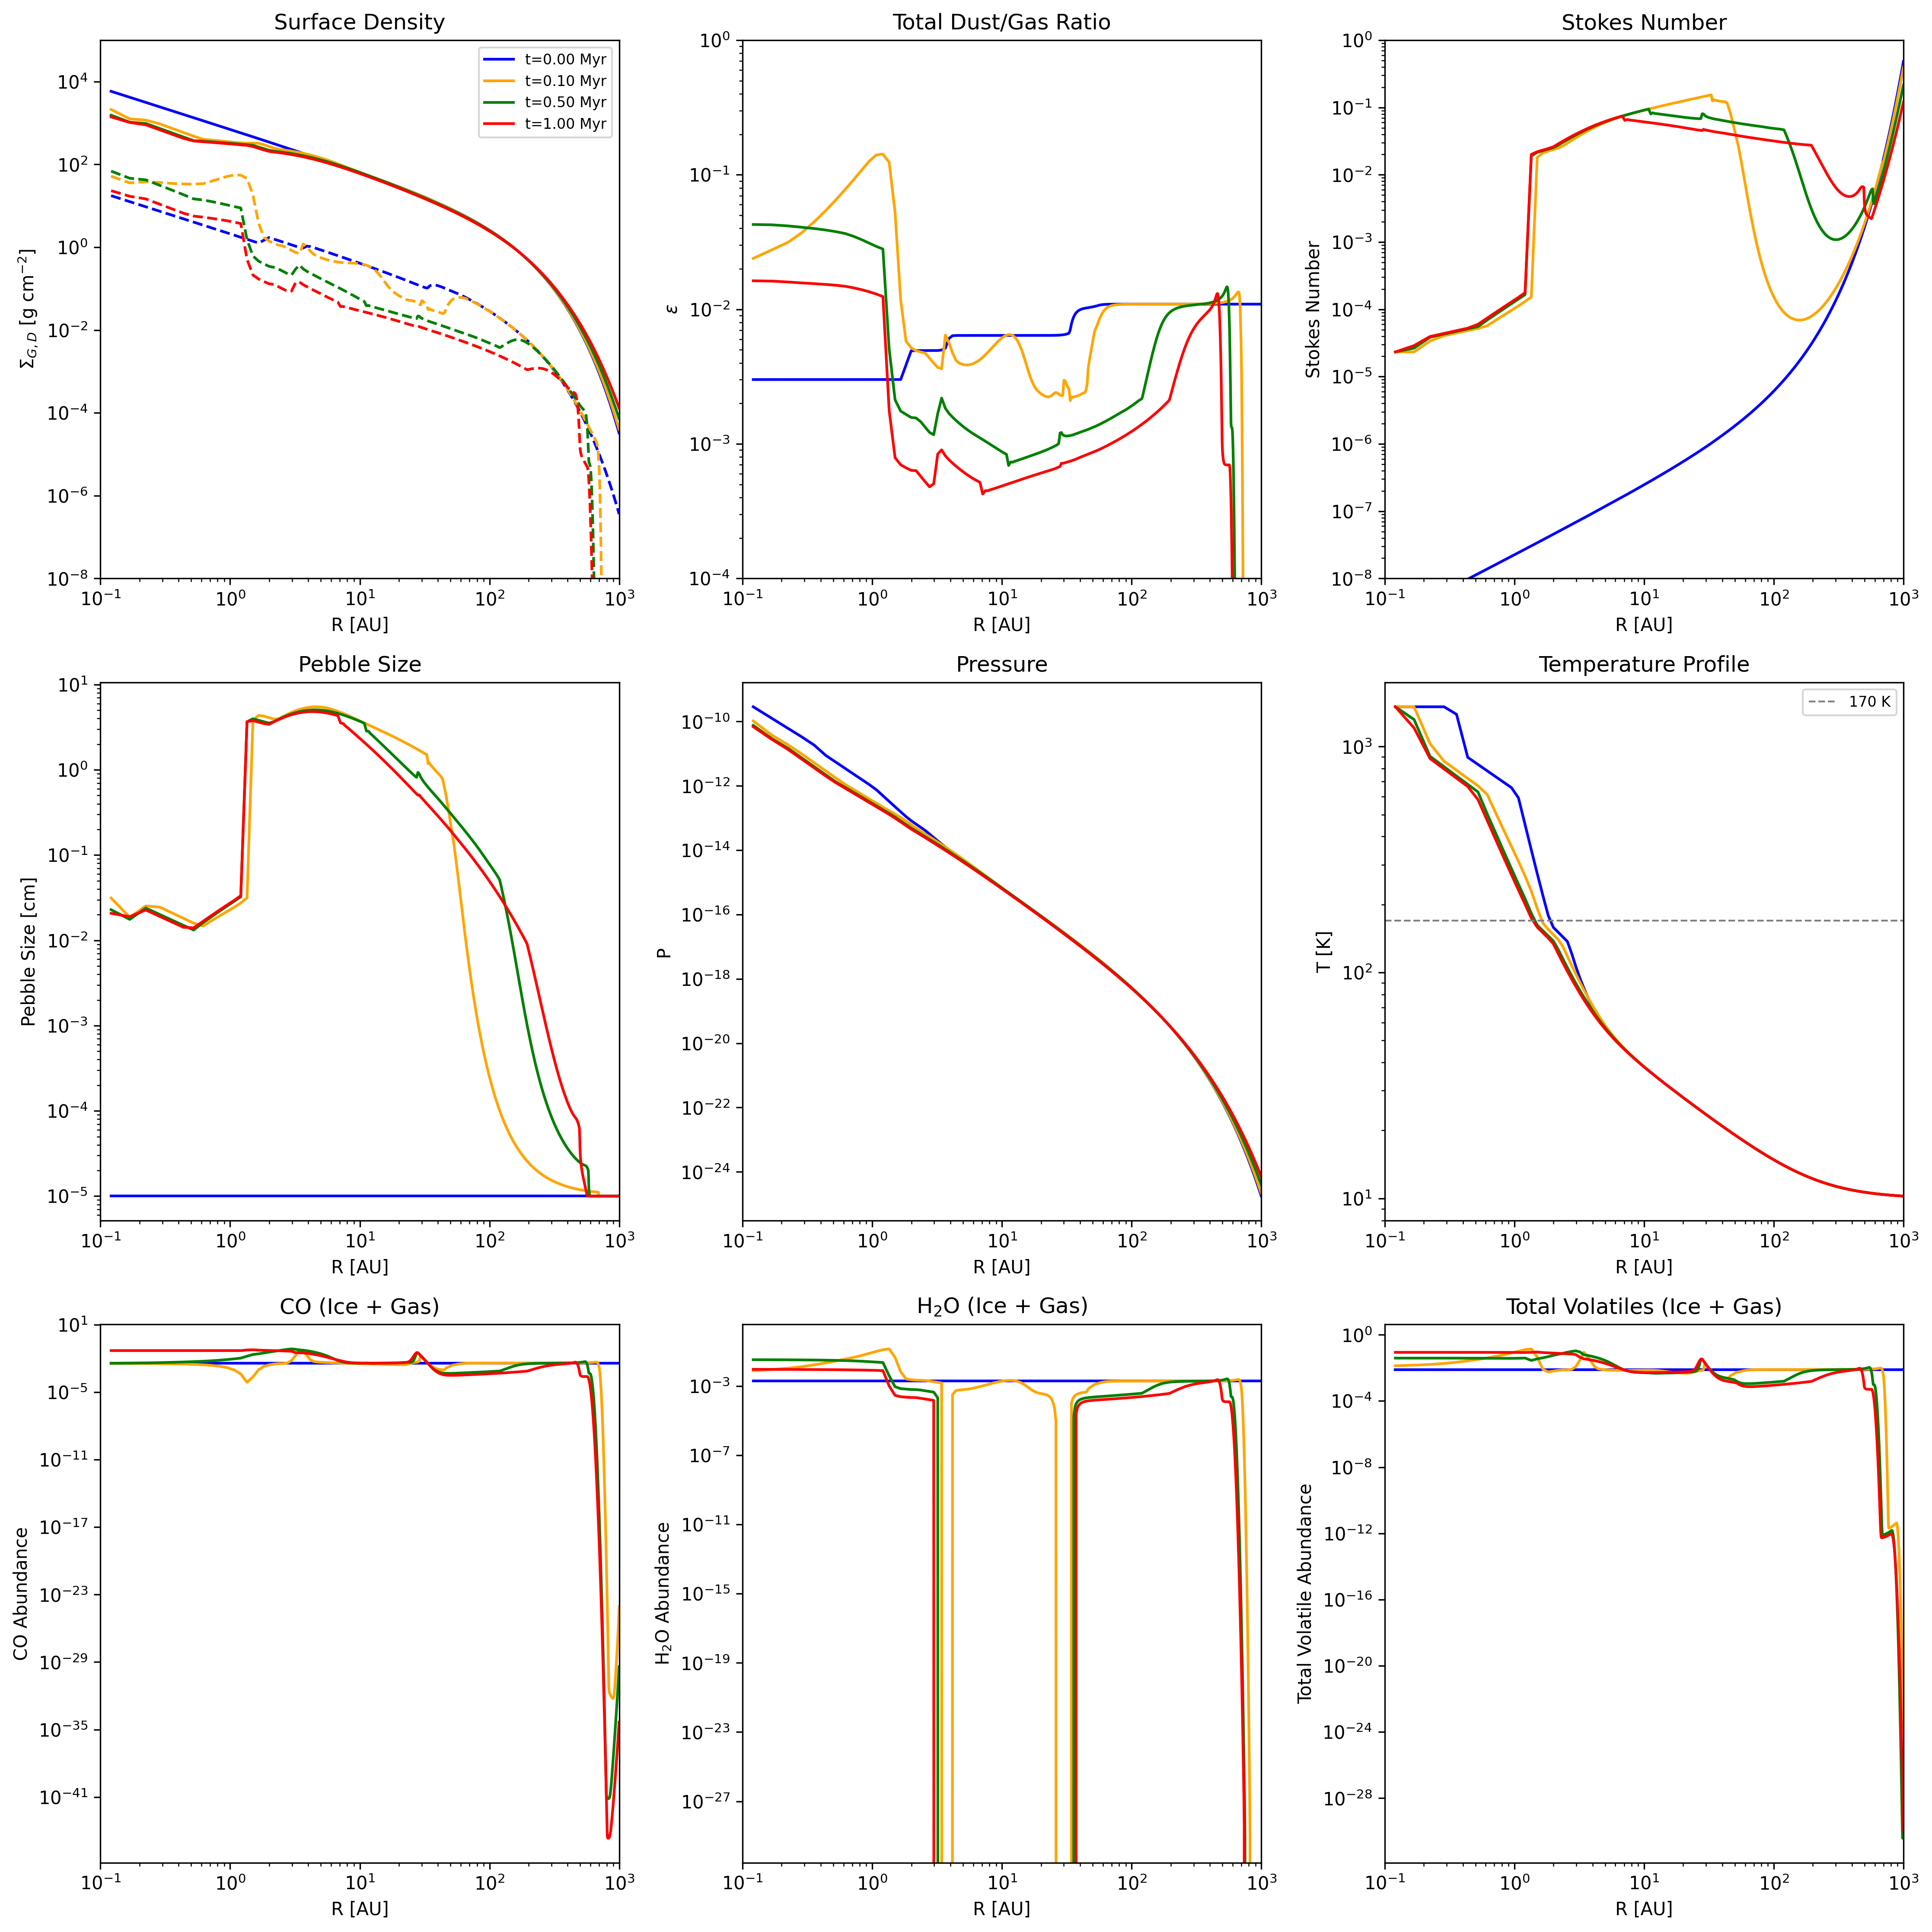


Chemistry species tracked: ['CO', 'CH4', 'CO2', 'H2O', 'N2', 'NH3', 'C-grain', 'Si-grain']


In [13]:
# Plot evolution results with dust properties and chemistry
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
lw = 1.5

# Get chemical species names and find indices
try:
    chem_species = disc.chem.ice.names
    idx_CO = chem_species.index('CO') if 'CO' in chem_species else None
    idx_H2O = chem_species.index('H2O') if 'H2O' in chem_species else None
    idx_CH4 = chem_species.index('CH4') if 'CH4' in chem_species else None
except (AttributeError, ValueError):
    idx_CO = idx_H2O = idx_CH4 = None

# Color cycle for time snapshots
from cycler import cycler
c = ['blue','orange','g','r']
ax_prop_cycle = cycler(color=c)

# 1. Surface density: Gas and Dust
ax = axes[0, 0]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['Sigma_G']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

i = 0
for line in snapshots['Sigma_D']:
    ax.loglog(disc.R, line, linestyle='dashed', lw=lw)
    i += 1
ax.set_ylim(1e-8, 1e5)
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
ax.set_title('Surface Density')
ax.legend(fontsize=8)
ax.set_xlim(R_in, R_out)

# 2. Dust-to-gas ratio (epsilon)
ax = axes[0, 1]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['dust_frac']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\epsilon$')
ax.set_title('Total Dust/Gas Ratio')
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-4, 1e0)

# 3. Stokes number
ax = axes[0, 2]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['St']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel('Stokes Number')
ax.set_title('Stokes Number')
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-8, 1e0)

# 4. Pebble size
ax = axes[1, 0]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['grain_size']:
    ax.loglog(disc.R, line, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel('Pebble Size [cm]')
ax.set_title('Pebble Size')
ax.set_xlim(R_in, R_out)

# 5. Pressure
ax = axes[1, 1]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['P']:
    ax.loglog(disc.R, np.abs(line), linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    i += 1
ax.set_xlabel('R [AU]')
ax.set_ylabel('P')
ax.set_title('Pressure')
ax.set_xlim(R_in, R_out)

# 6. Temperature profile
ax = axes[1, 2]
ax.set_prop_cycle(ax_prop_cycle)

i = 0
for line in snapshots['T']:
    ax.loglog(disc.R, line, linestyle='solid', lw=lw)
    i += 1
ax.axhline(170, ls = 'dashed', label='170 K', color = 'gray', lw=1)

ax.set_xlabel('R [AU]')
ax.set_ylabel('T [K]')
ax.set_title('Temperature Profile')
ax.set_xlim(R_in, R_out)
ax.legend(fontsize=8)

# 7. CO abundance (ice + gas combined)
ax = axes[2, 0]
ax.set_prop_cycle(ax_prop_cycle)

if idx_CO is not None:
    i = 0
    for ice_data, gas_data in zip(snapshots['chem_ice'], snapshots['chem_gas']):
        CO_total = ice_data[idx_CO] + gas_data[idx_CO]  # Sum of ice and gas
        ax.loglog(disc.R, CO_total, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        i += 1
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'CO Abundance')
    ax.set_title('CO (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'CO not found in chemistry', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('CO (Ice + Gas)')

# 8. H2O abundance (ice + gas combined)
ax = axes[2, 1]
ax.set_prop_cycle(ax_prop_cycle)

if idx_H2O is not None:
    i = 0
    for ice_data, gas_data in zip(snapshots['chem_ice'], snapshots['chem_gas']):
        H2O_total = ice_data[idx_H2O] + gas_data[idx_H2O]  # Sum of ice and gas
        ax.loglog(disc.R, H2O_total, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        i += 1
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'H$_2$O Abundance')
    ax.set_title(r'H$_2$O (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'H2O not found in chemistry', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(r'H$_2$O (Ice + Gas)')

# 9. Total volatile abundance (sum of volatile molecules, excluding grains)
ax = axes[2, 2]
ax.set_prop_cycle(ax_prop_cycle)

if idx_CO is not None:
    i = 0
    for ice_data, gas_data in zip(snapshots['chem_ice'], snapshots['chem_gas']):
        # Sum all volatiles (exclude grain species which typically have 'grain' in name)
        volatile_ice = np.sum([ice_data[j] for j in range(len(chem_species)) 
                               if 'grain' not in chem_species[j]], axis=0)
        volatile_gas = np.sum([gas_data[j] for j in range(len(chem_species)) 
                               if 'grain' not in chem_species[j]], axis=0)
        volatile_total = volatile_ice + volatile_gas
        ax.loglog(disc.R, volatile_total, linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        i += 1
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'Total Volatile Abundance')
    ax.set_title('Total Volatiles (Ice + Gas)')
    ax.set_xlim(R_in, R_out)
else:
    ax.text(0.5, 0.5, 'Chemistry data not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Total Volatiles (Ice + Gas)')

plt.tight_layout()
plt.show()

# Print chemistry species for reference
if idx_CO is not None:
    print(f"\nChemistry species tracked: {chem_species}")

### I'll do an example of torque maps computation here. 

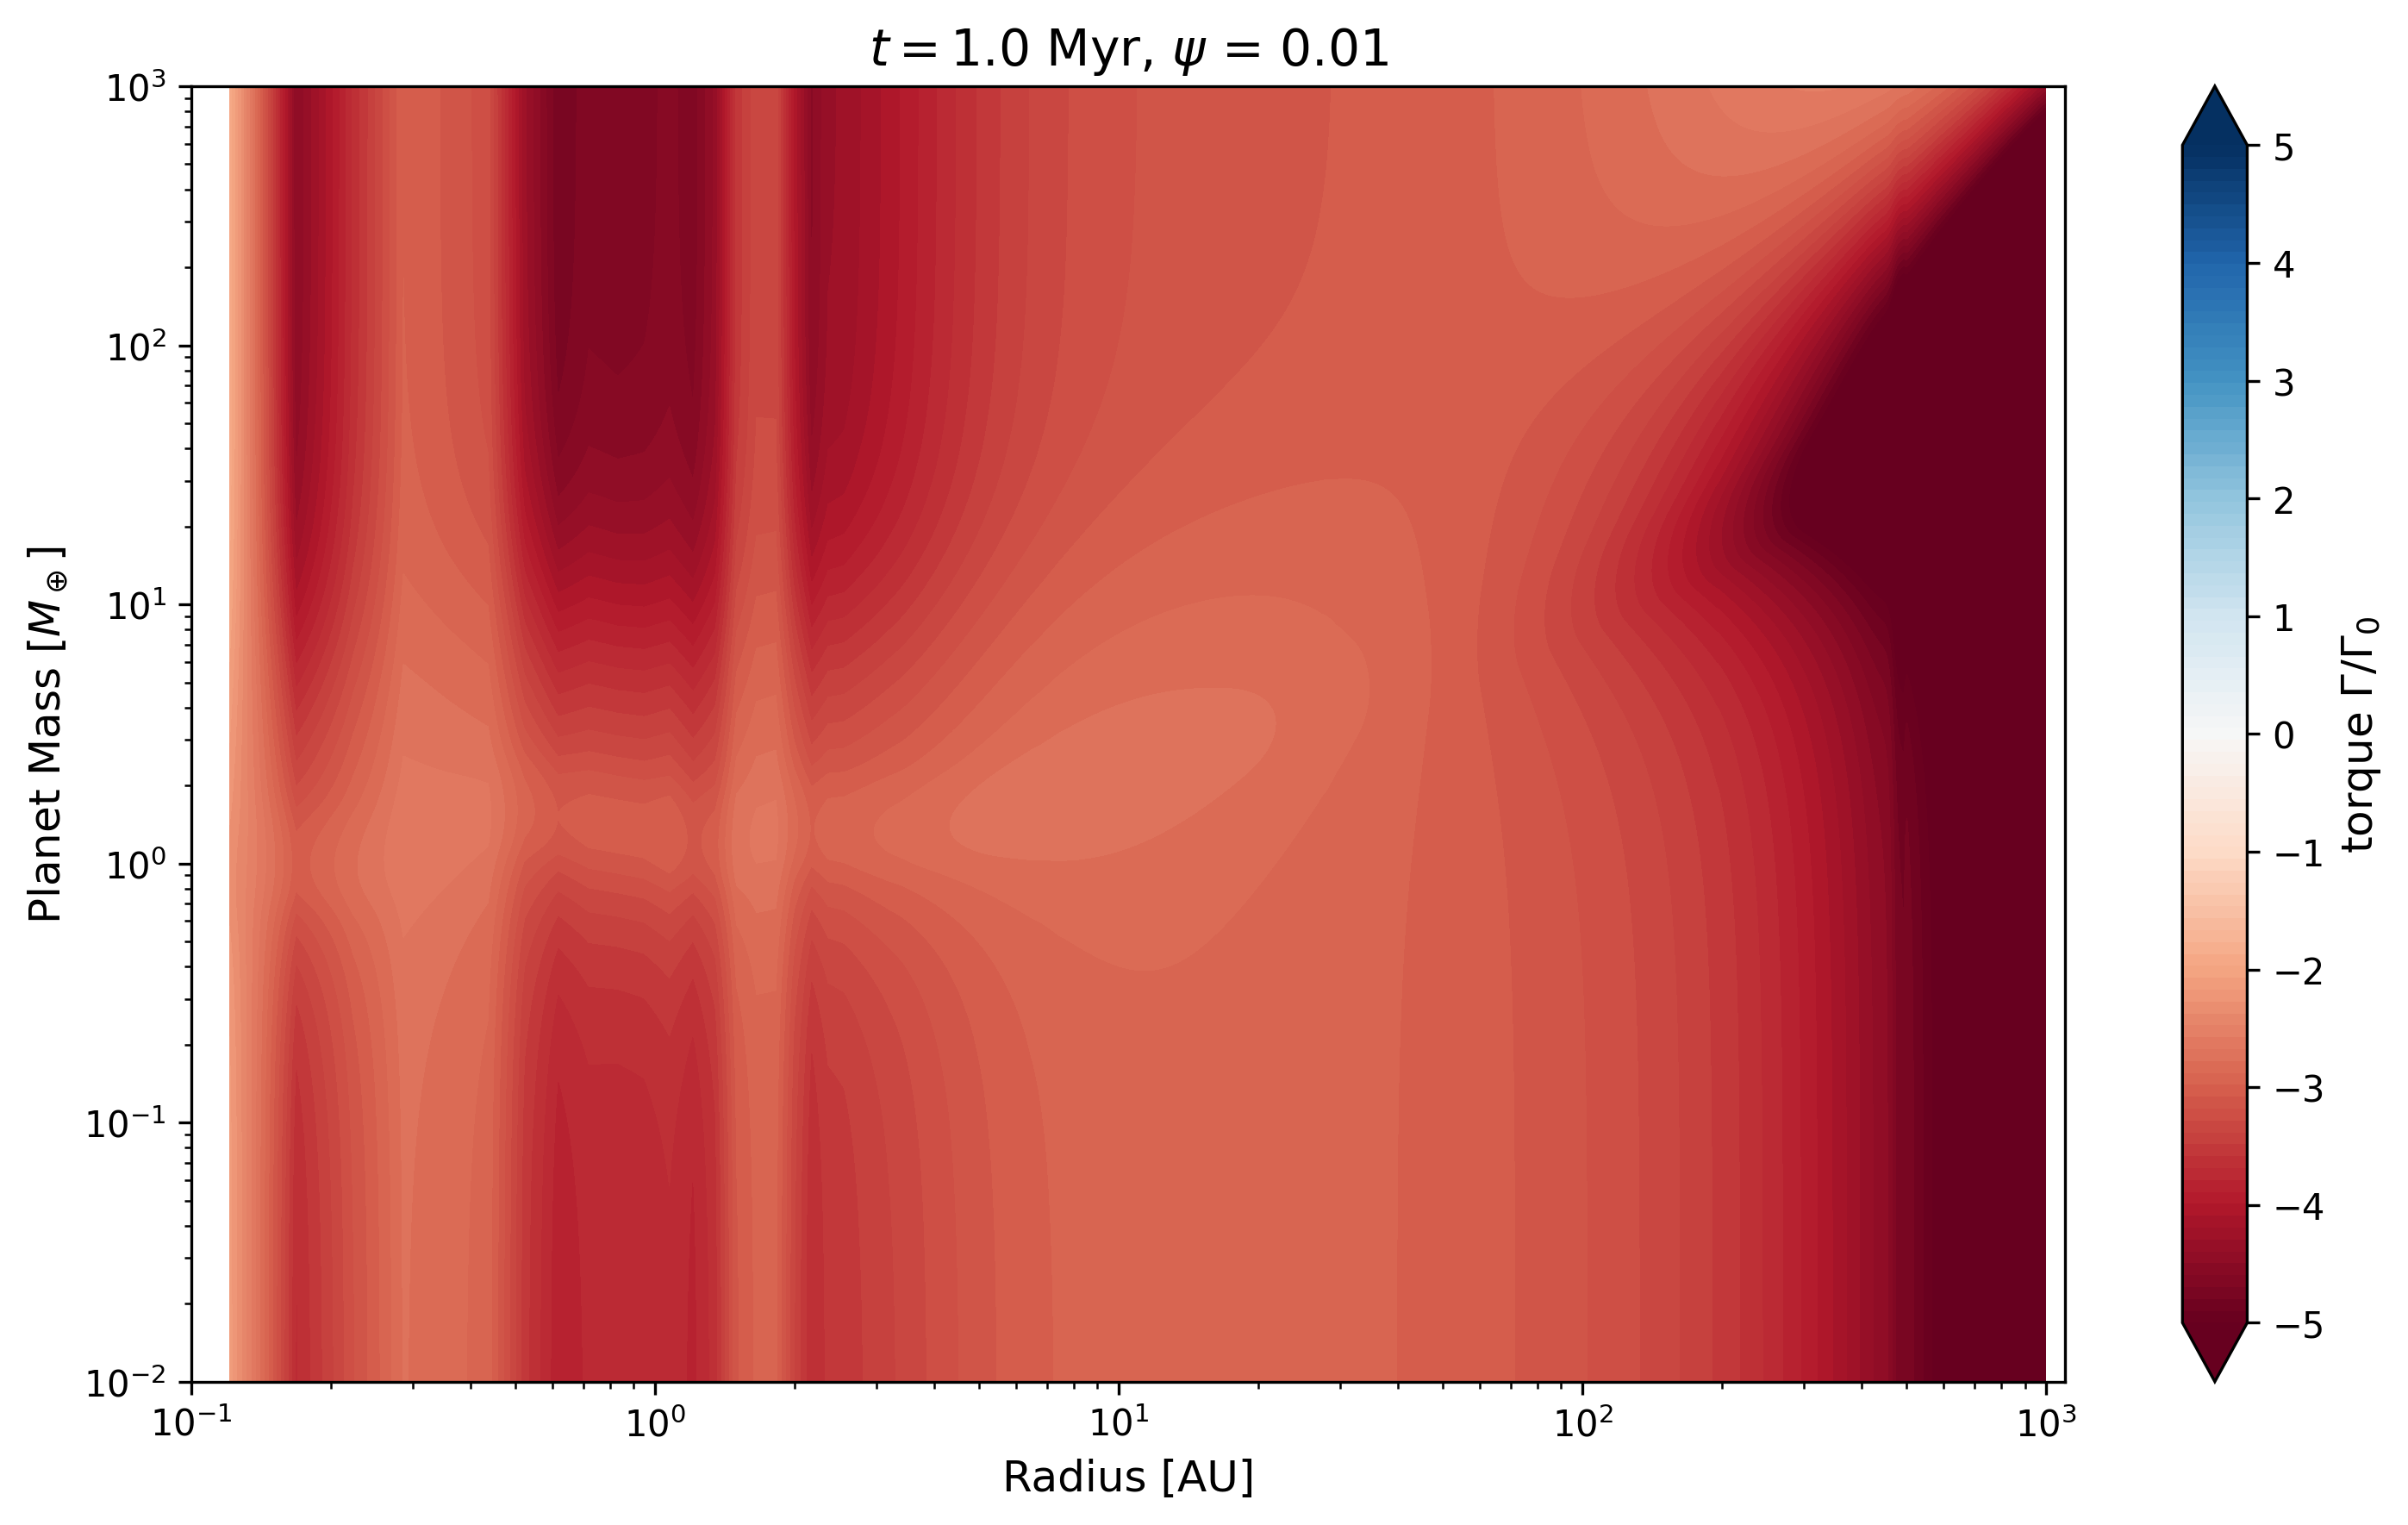

In [14]:
from DiscEvolution import planet_formation as pf

# 1. Create Migration Model
TypeI = pf.TypeIMigration(disc) #Creates a Type I migration object from the disc object

# 2. Create M-R diagram 
mass_array = np.logspace(-2,3,Ncells) #Mearth required by compute_torque function
radius_array = disc.R #AU

R_grid, M_grid = np.meshgrid(radius_array, mass_array) #2D grid from two 1D arrays
Torque_map = np.zeros_like(R_grid) #initialize 2D grid with all values zero 

# 3. Compute Torques
for i, Mp in enumerate(mass_array):
    # Pass Mp as an array of the same shape as radius_array
    Mp_array = np.ones_like(radius_array) * Mp #entire row with said mass value
    # Compute the total torque for said mass at each R 
    Torque_map[i, :] = TypeI.compute_torque_raw(radius_array, Mp_array) #TODO get warnings after first import from the main method in planet_formation.py 

# 4. Normalize by Gamma_0
## The function already computes Gamma_0 (norm) and scales the torque with it, so we want to reverse this
## I created a new function that doesn't scale the torques so this step is not necessary anymore
##essentially instead of Gamma*Gamma_0 we return Gamma

# 5. Plot Torque Map 
from matplotlib import colors


fig, ax = plt.subplots(figsize=(10, 6))

# Colormap (Red = Inward/negative, Blue = Outward/Positive)
norm = colors.TwoSlopeNorm(vmin=-5.0, vcenter=0.0, vmax=5.0)
symmetric_levels = np.linspace(-5.0, 5.0, 100) #Explicitly define 100 levels from -5 to +5
cp = ax.contourf(R_grid, M_grid, Torque_map, levels=symmetric_levels, cmap='RdBu', norm=norm, extend='both')

# Zero-Torque Planet Traps
trap_lines = ax.contour(R_grid, M_grid, Torque_map, levels=[0.0], colors='black', linewidths=1.0)

# Colorbar
cbar = plt.colorbar(cp, ax=ax, ticks = np.arange(-5.0, 6.0, 1.0))
cbar.set_label(rf'torque $\Gamma / \Gamma_0$', fontsize=12)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 1100) 
#ax.set_ylim(0.1, 100)

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(rf'Planet Mass [$M_\oplus$]', fontsize=12)
ax.set_title(rf'$t = {driver.t / (1e6* 2 * np.pi)}$ Myr, $\psi$ = {disc._gas._psi}', fontsize=14)
    
plt.tight_layout()
#plt.savefig('output/TaboneZhu100-Torques.jpg', dpi=300)
plt.show()

In [15]:
float(np.min(Torque_map)) , float(np.max(Torque_map))

(-10.742326257047381, -1.8886310064596785)

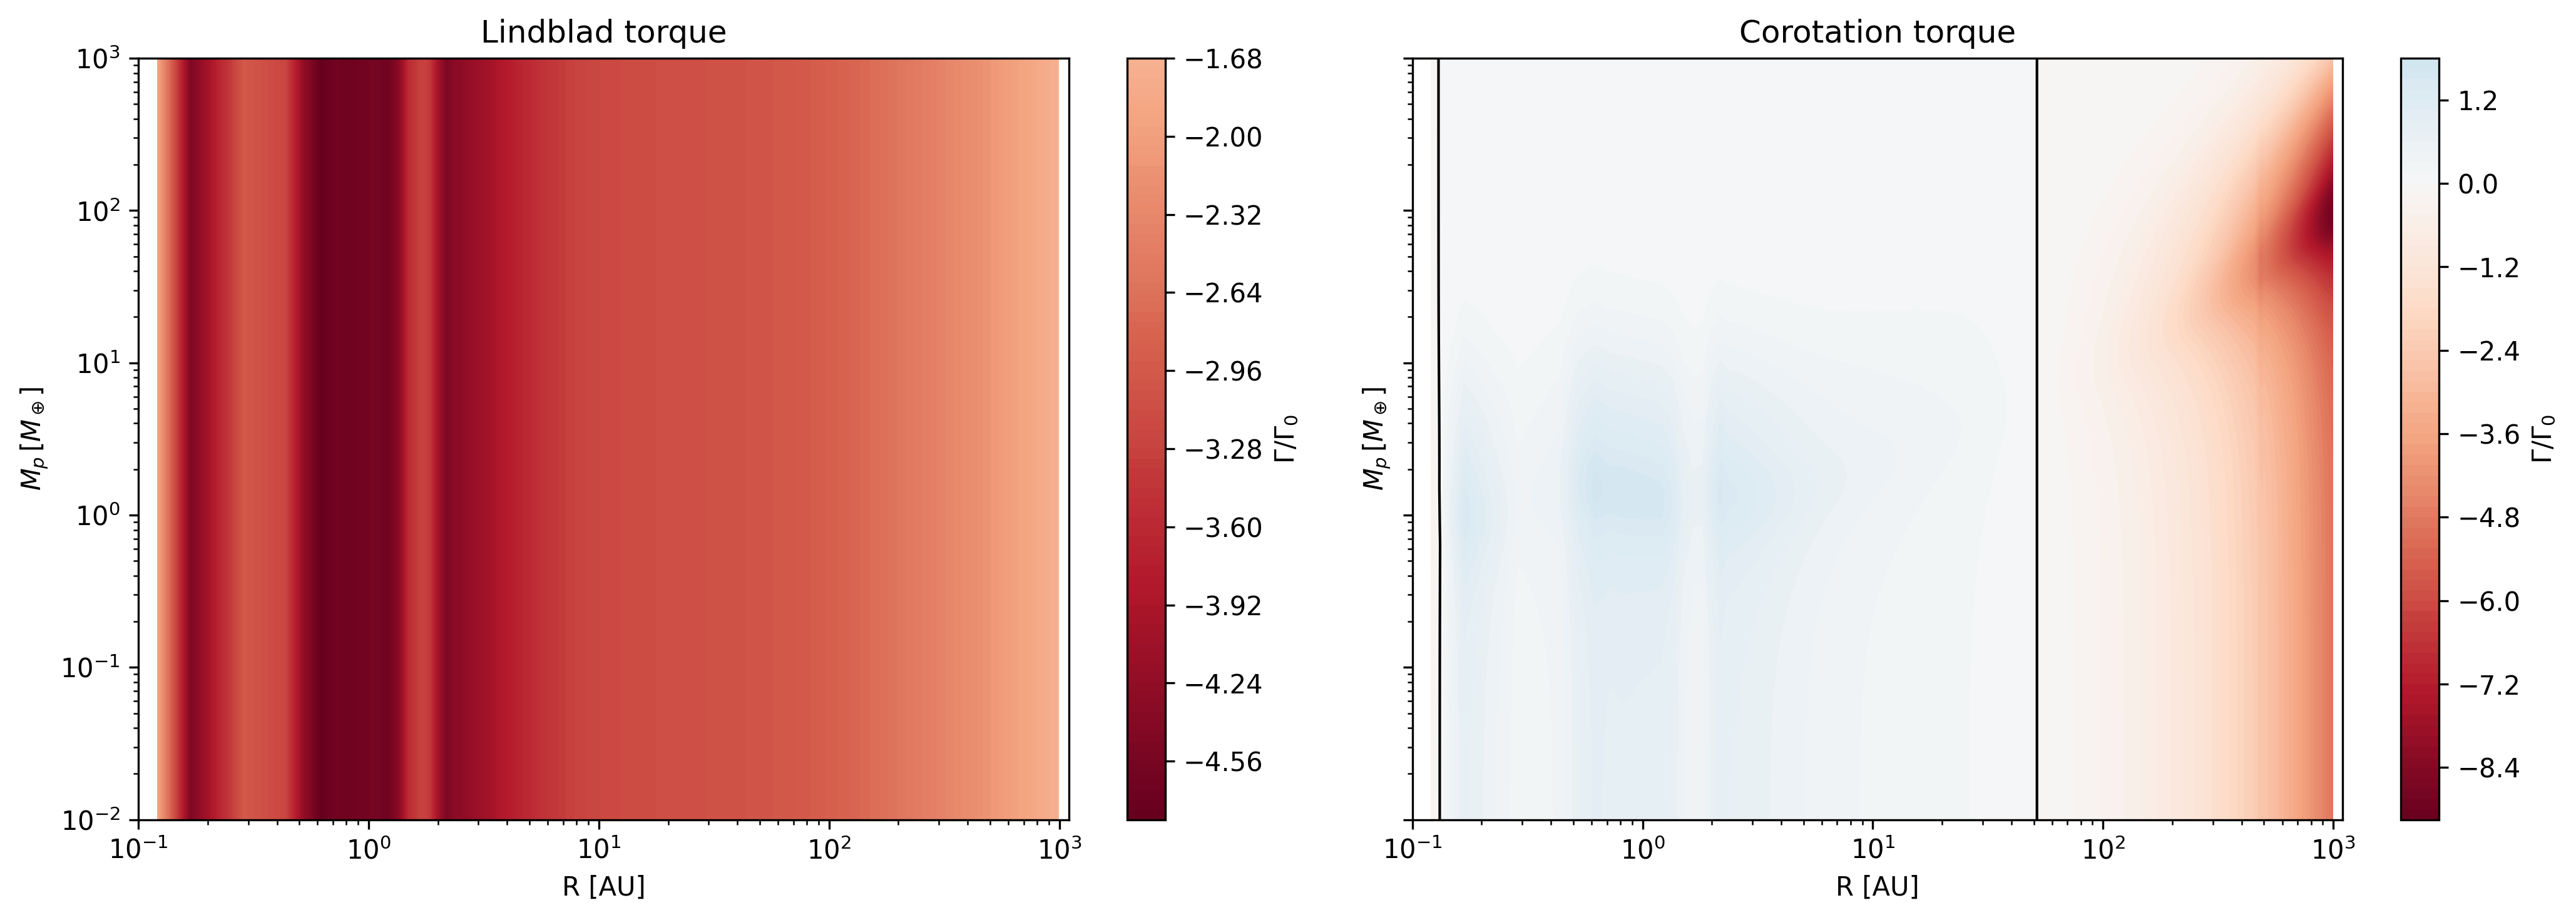

In [16]:
from matplotlib.colors import CenteredNorm
from matplotlib import colors
from DiscEvolution import planet_formation as pf

TypeI = pf.TypeIMigration(disc)

R_grid_1d = disc.R
M_grid_1d = np.logspace(-2, 3, Ncells)

GL = np.zeros((len(M_grid_1d), len(R_grid_1d)))
GC = np.zeros_like(GL)

for i, M in enumerate(M_grid_1d):
    GL[i], GC[i] = TypeI.compute_torque_components_raw(R_grid_1d, M)

R_grid, M_grid = np.meshgrid(R_grid_1d, M_grid_1d)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, title in zip(axes, [GL, GC], ['Lindblad', 'Corotation']):
    cmin = np.nanmin(data)
    cmax = np.nanmax(data)
    #norm = colors.TwoSlopeNorm(vmin=cmin, vcenter=0.0, vmax=cmax)
    norm = CenteredNorm()
    cp = ax.contourf(R_grid, M_grid, data, levels=100, cmap='RdBu', norm=norm)
    ax.contour(R_grid, M_grid, data, levels=[0.0], colors='black', linewidths=1.0)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('R [AU]'); ax.set_ylabel(r'$M_p\,[M_\oplus]$')
    ax.set_title(title + ' torque')
    ax.set_xlim(0.1, 1100) 
    plt.colorbar(cp, ax=ax, label=r'$\Gamma / \Gamma_0$')

plt.tight_layout()
plt.show()

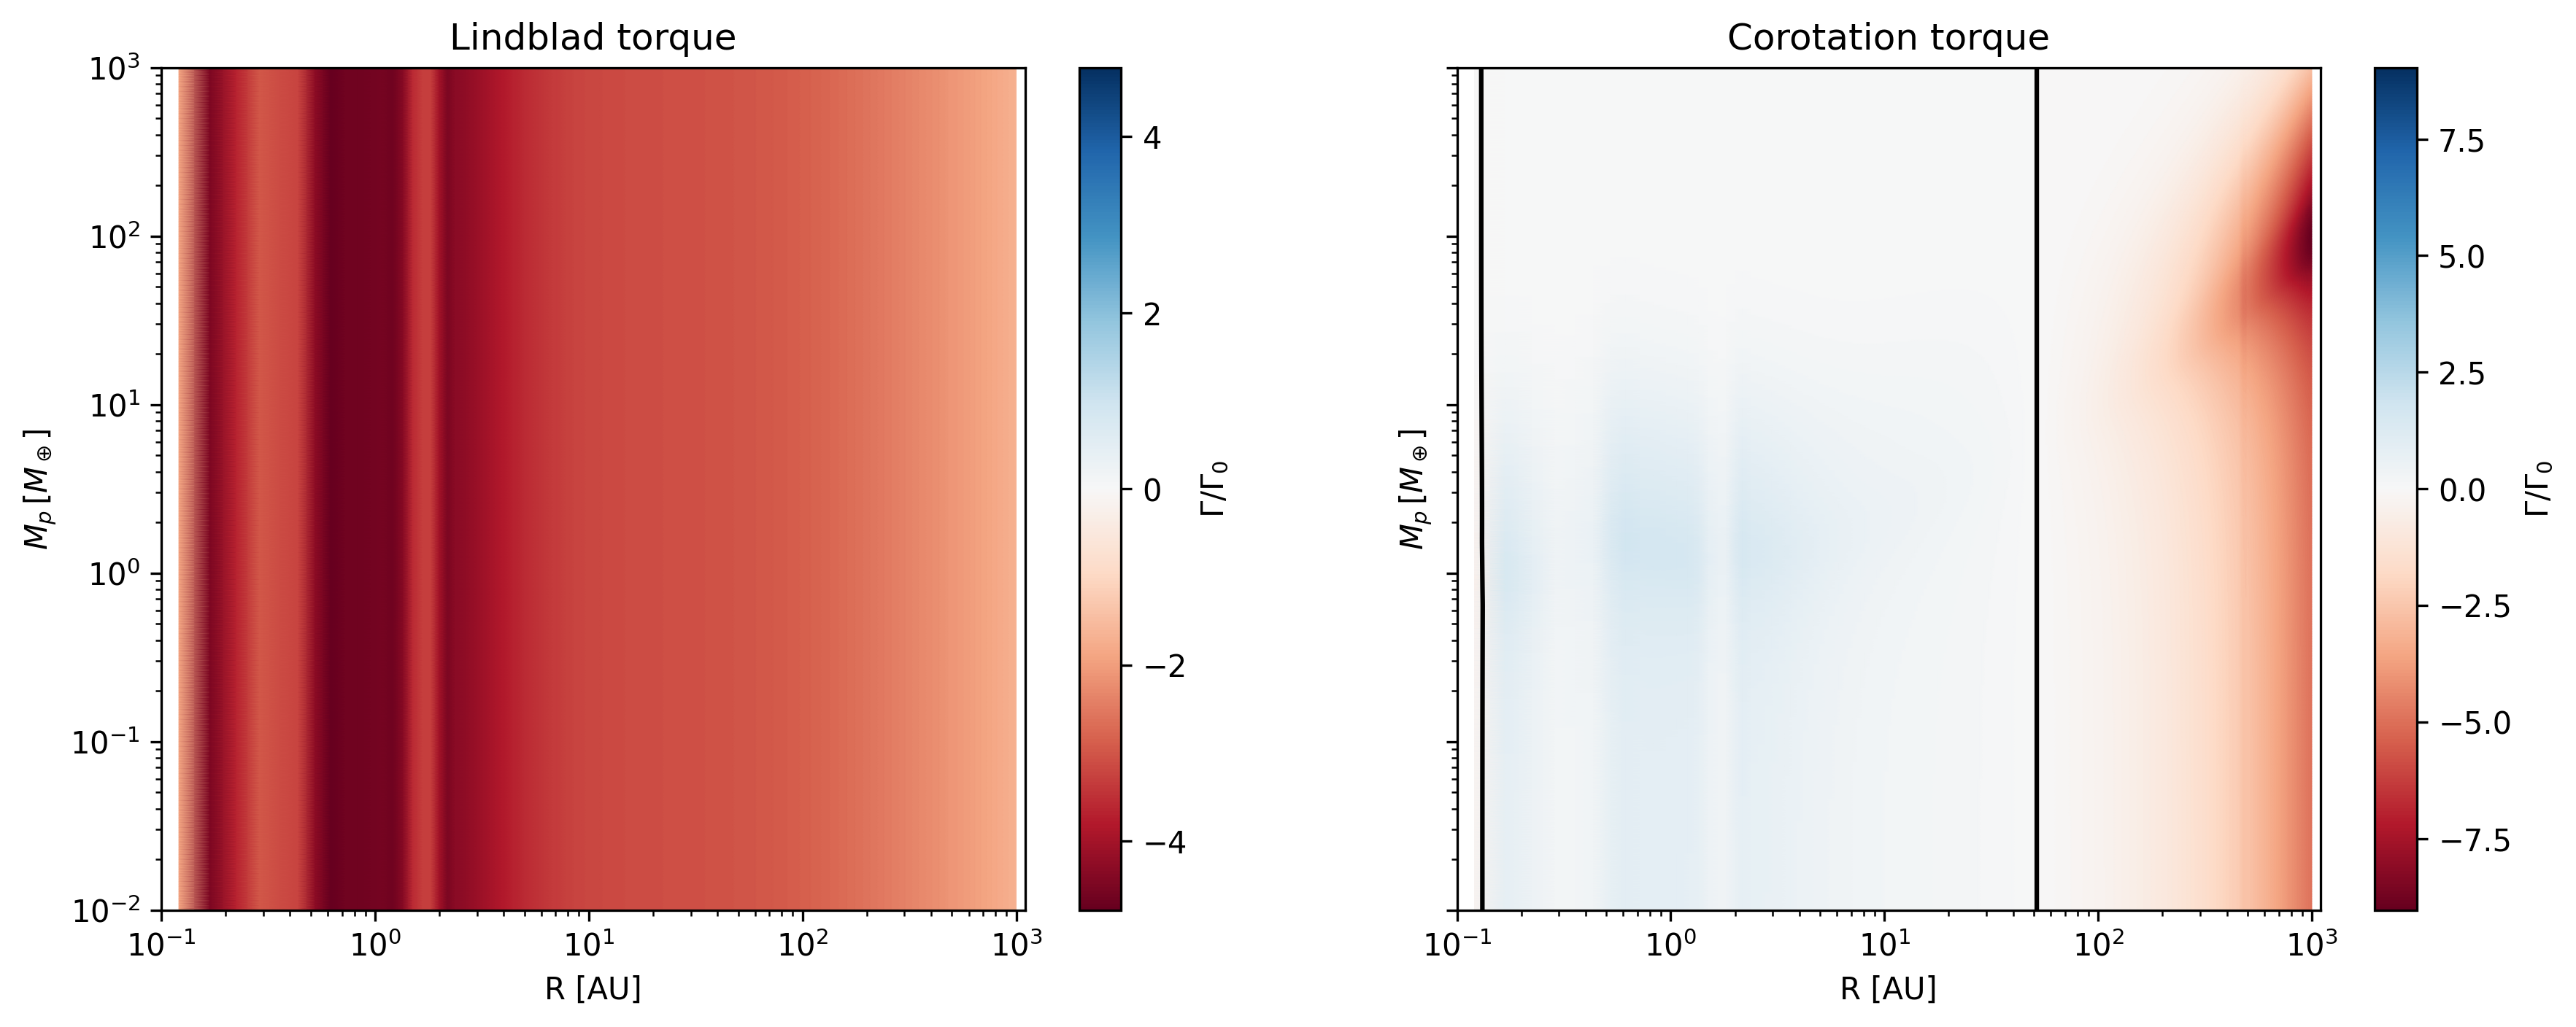

In [17]:
from matplotlib.colors import CenteredNorm
from DiscEvolution import planet_formation as pf

TypeI = pf.TypeIMigration(disc) #Creates a Type I migration object from the disc object

R_grid_1d = disc.R                          # AU — same as cell below
M_grid_1d = np.logspace(-2, 3, Ncells)     # Earth masses — same as cell below

GL = np.zeros((len(M_grid_1d), len(R_grid_1d)))
GC = np.zeros_like(GL)

for i, M in enumerate(M_grid_1d):
    GL[i], GC[i] = TypeI.compute_torque_components_raw(R_grid_1d, M)

R_grid, M_grid = np.meshgrid(R_grid_1d, M_grid_1d)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
norm = CenteredNorm()  # diverging around 0

for ax, data, title in zip(axes, [GL, GC], ['Lindblad', 'Corotation']):
    norm = CenteredNorm()
    im = ax.pcolormesh(R_grid, M_grid, data, cmap='RdBu', norm=norm, shading='gouraud')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('R [AU]'); ax.set_ylabel(r'$M_p\,[M_\oplus]$')
    ax.set_title(title + ' torque')
    plt.colorbar(im, ax=ax, label=r'$\Gamma / \Gamma_0$')
    ax.set_xlim(0.1, 1100) 
    ax.contour(R_grid, M_grid, data, levels=[0], colors='k', linewidths=1.5)


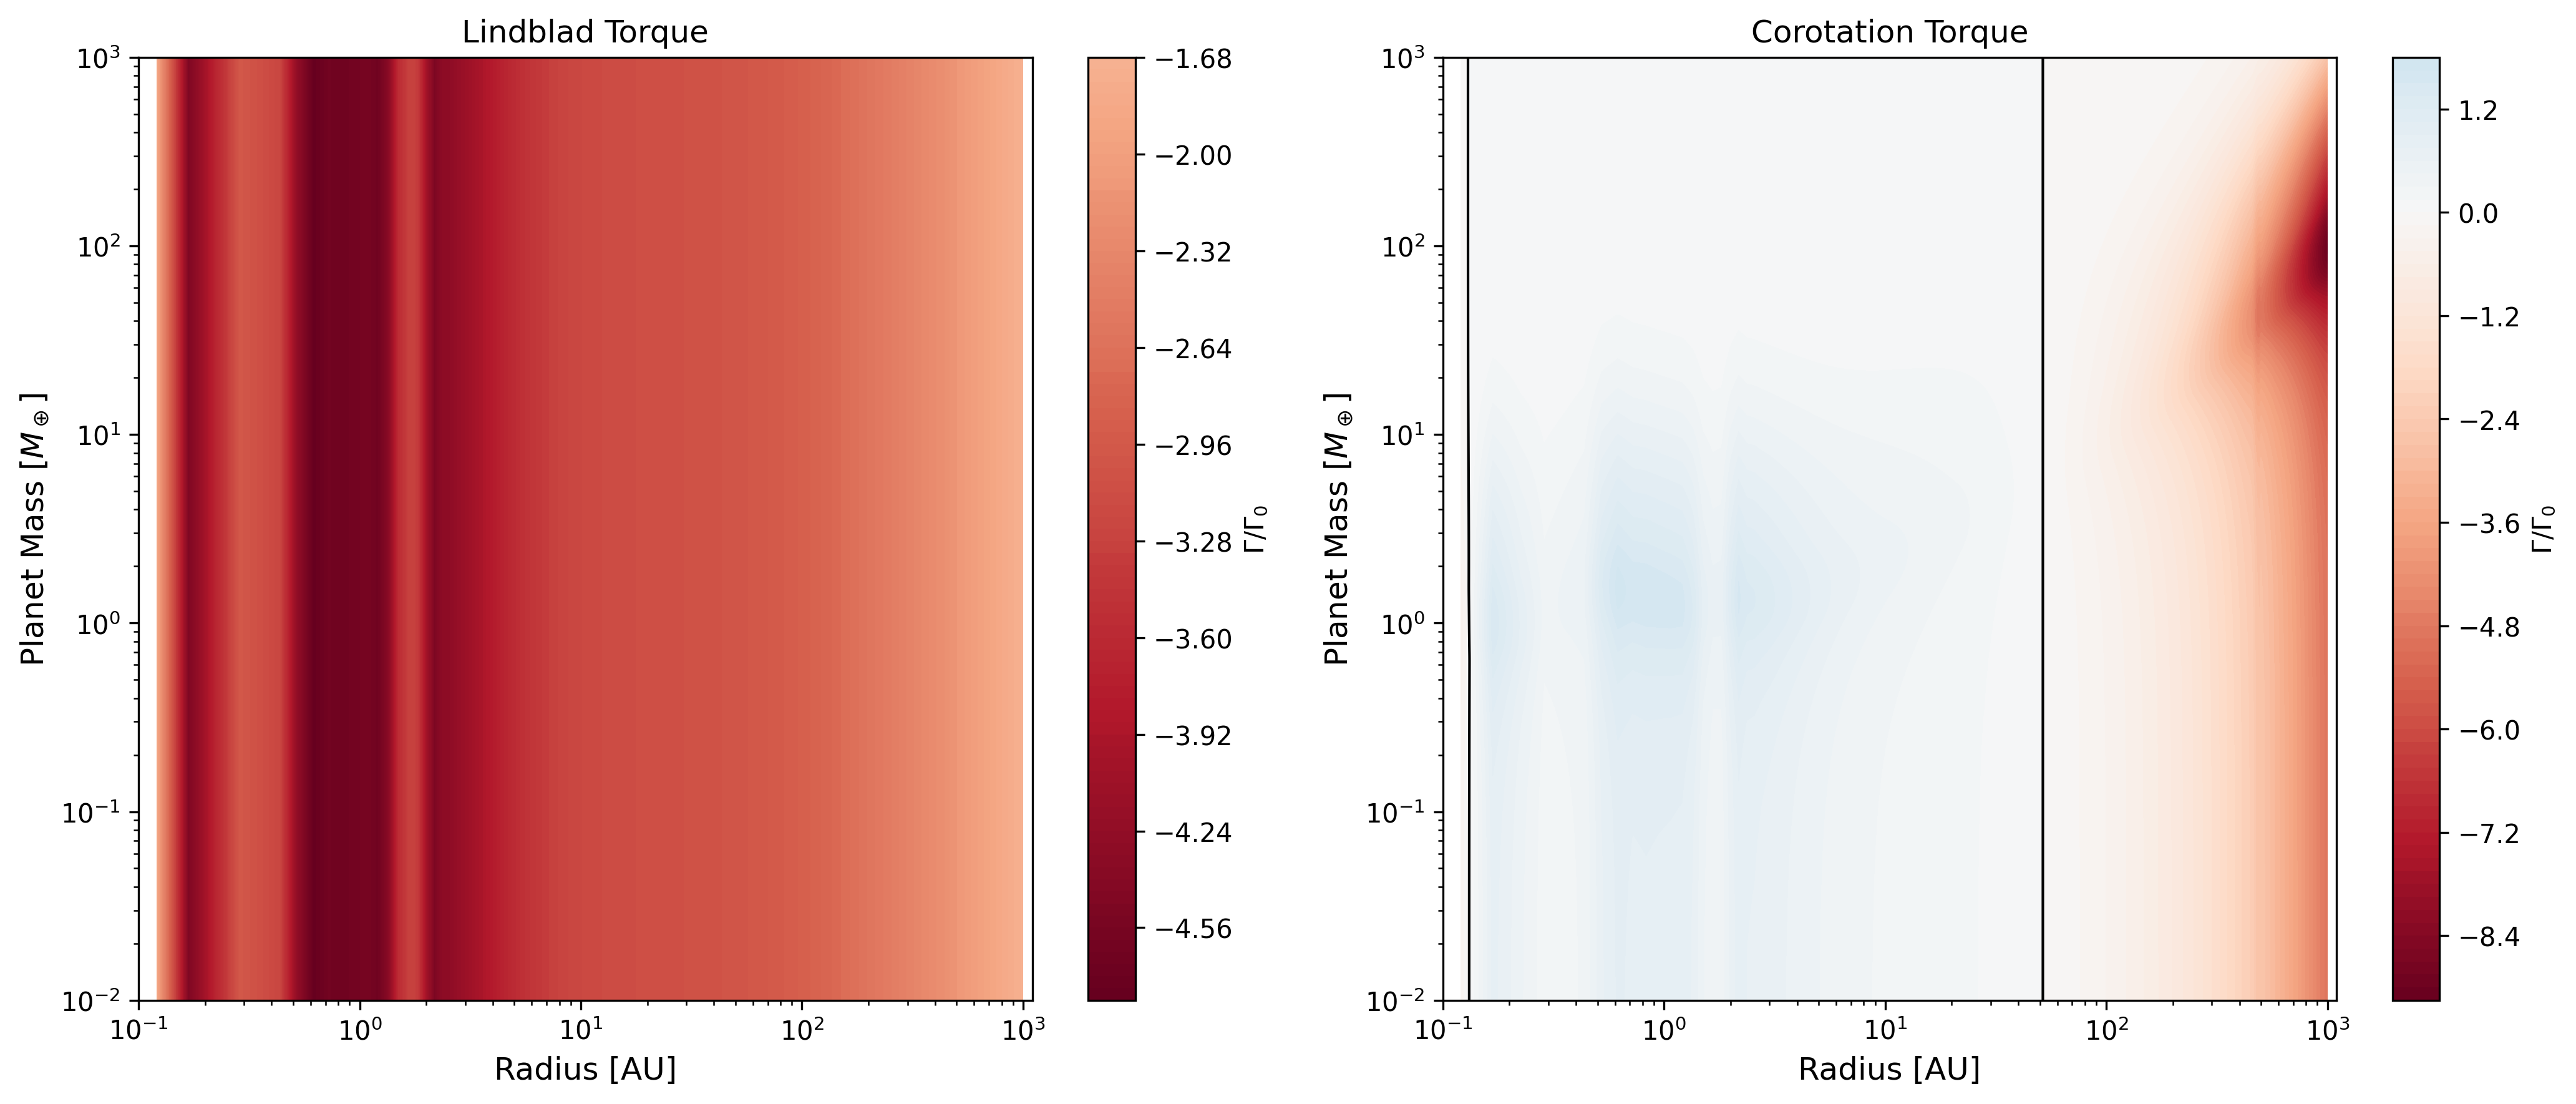

In [18]:
from DiscEvolution import planet_formation as pf
from matplotlib import colors

# 1. Create Migration Model
TypeI = pf.TypeIMigration(disc)

# 2. Create M-R diagram 
mass_array = np.logspace(-2, 3, Ncells)
radius_array = disc.R

# Create separate 2D maps for Lindblad and corotation components
GL_map = np.zeros((len(mass_array), len(radius_array)))
GC_map = np.zeros((len(mass_array), len(radius_array)))

# 3. Compute Torque Components
for i, Mp in enumerate(mass_array):
    Mp_array = np.ones_like(radius_array) * Mp
    GL_map[i, :], GC_map[i, :] = TypeI.compute_torque_components_raw(radius_array, Mp_array)

R_grid, M_grid = np.meshgrid(radius_array, mass_array)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in zip(axes, [GL_map, GC_map], ['Lindblad', 'Corotation']):
    norm = colors.CenteredNorm()  # independent per subplot
    cp = ax.contourf(R_grid, M_grid, data, levels=100, cmap='RdBu', norm=norm)
    ax.contour(R_grid, M_grid, data, levels=[0], colors='black', linewidths=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Radius [AU]', fontsize=12)
    ax.set_ylabel(r'Planet Mass [$M_\oplus$]', fontsize=12)
    ax.set_title(title + ' Torque', fontsize=12)
    ax.set_xlim(0.1, 1100) 
    cbar = plt.colorbar(cp, ax=ax, label=r'$\Gamma / \Gamma_0$')

plt.tight_layout()
plt.show()
